# Batch velocity-FFT post-processing of PIVlab runs

Companion to `batch_VelocityPSD.ipynb`. Same batch/calibration/ROI machinery,
but instead of a Welch **power spectral density** it computes, for **each grid
point** in the ROI, the single-sided **FFT amplitude spectrum** of the two
velocity components `U(t)` and `V(t)` (`np.fft.rfft`, mean removed, optional
window with amplitude correction). The per-point spectra are then **averaged
over the whole ROI**.

- Per run it writes `<run>/PostProcessing/VelocityFFT.npz`
  (`f`, `amp_u`, `amp_v`, `amp_total = amp_u + amp_v`, all averaged over the ROI).
- Across all runs it writes `VelocityFFT_summary.csv` / `.xlsx` at `BASE_DIR`.
- Final figure `VelocityFFT_colormap_vs_fstar.png`: a colormap of the ROI-averaged
  amplitude spectrum over all runs — **x = f\* = f_lib/f_rot**, **y = FFT
  frequency**, colour = amplitude.

**Difference from the PSD notebook.** The FFT amplitude spectrum has units of the
signal (m/s), not (m/s)^2/Hz, and — unlike Welch — uses the full record with no
segment averaging, so it has the finest frequency resolution `df = fps/nframes`
but a noisier (un-averaged) estimate. Amplitudes are single-sided: every bin
except DC (and Nyquist for even-length records) is doubled, and the window's
coherent gain is divided out so a pure tone reads its true amplitude.

**Duplicate runs**: when several runs share the same parameters (same
`frot/flib/dphi`), only the *second* acquisition is kept in the colormap
(i.e. the `SSn` with the highest index — `SS2` beats `SS1`).

Calibration is read from the **last row** of `acquisition_log.txt`
(`dt_vel = pulse_sep`, `fps = cam_fps`); `xscale = yscale = 1.2323e-4 m/px`.

Set the config in the next cell, then *Run All*. To test on a couple of folders
first, list their names in `ONLY_RUNS`.

**Polarization.** Besides the amplitude spectra, each run stores the ROI-mean power spectra `powerU_mean`/`powerV_mean` and the polarization ratio `powerRatio` = ROI mean of the per-point `powerV/powerU` (with `powerRatio_std`, `powerRatio_med`, `powerRatio_p25`, `powerRatio_p75`). The figure `Velocity_polarization.png` plots it against the inertial-wave relation `2*((2*frot/f)**2 - 1)`. The ratio is drawn both as the ROI mean and as the median with a 25-75 percentile band.

In [91]:
import os
import re
import glob
import numpy as np
import pandas as pd
from scipy.io import loadmat
from scipy.signal import get_window
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

%matplotlib widget

In [92]:
# --- Configuration --------------------------------------------------------- #
BASE_DIR = ("/Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/"
            "TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/k6_TopBottom")

PIV_FILENAME = "PIVlab_results_uncalibrated.mat"
LOG_FILENAME = "acquisition_log.txt"
RESULT_FILENAME = "VelocityFFT.npz"          # per-run output (in PostProcessing/)

# Only runs without an existing result are processed unless this is True.
REPROCESS_ALL = True

# Restrict processing to these run-folder names (for testing). Empty -> all runs.
ONLY_RUNS = []

# Pixel calibration (notebook value). Same in x and y.
XSCALE = 1.2323e-4   # m/px
YSCALE = XSCALE

# Fixed ROI, calibrated (metres): [(x0, y0), (x1, y1)] (opposite corners).
PTS_ROI = [(0.02002585173778408, 0.13110555228124998),
           (0.19561960104659090, 0.00659505254715910)]

# PIVlab pairs images (1+2, 3+4, ...), so every velocity field consumes this
# many camera frames. The PIV field sampling frequency is therefore
# f_piv = cam_fps / FRAMES_PER_FIELD (cam_fps in the log is the camera frame
# rate, i.e. TWICE the rate at which PIV fields are produced).
FRAMES_PER_FIELD = 2

# If the acquisition log cannot be read, the run stays UNCALIBRATED: velocity
# dt, PIV sampling and both spatial scales fall back to 1, so velocities are in
# px/frame, positions in px, and timestamps in frame index.
UNCAL_DT = 1.0
UNCAL_FPS = 1.0
UNCAL_SCALE = 1.0

# Folder-name -> physical value conversions (Hz). Folder tokens are integers,
# e.g. 'frot050' -> 0.50 Hz, 'flib0400' -> 0.400 Hz, 'flib1500' -> 1.500 Hz.
FROT_DIVISOR = 100.0
FLIB_DIVISOR = 1000.0

# --- FFT settings ---------------------------------------------------------- #
# Per-point single-sided amplitude spectrum of U(t) and V(t) over the FULL
# record (np.fft.rfft). Finest resolution df = fps / nframes, but no segment
# averaging (noisier than Welch).
FFT_WINDOW = "hann"     # taper before the FFT to suppress spectral leakage;
                        # "boxcar" or None -> no window. Coherent gain is divided
                        # out so amplitudes stay calibrated.
FFT_DETREND = "constant"   # "constant" removes the per-point mean (kills DC);
                           # None keeps it.

# --- Colormap settings ----------------------------------------------------- #
# Which velocity component to show in the colormap:
#   "u"      -> fft(U)         amplitude |FFT(U)|
#   "v"      -> fft(V)         amplitude |FFT(V)|
#   "total"  -> fft(U)+fft(V)  summed amplitude
#   "powerU" -> |FFT(U)|^2     ROI-averaged power spectrum of U
#   "powerV" -> |FFT(V)|^2     ROI-averaged power spectrum of V
PLOT_COMPONENT = "total"
# Restrict which runs enter the plots. Maps a summary column to an allowed value
# (or list of values); {} -> use every run. Examples:
#   {"dphi_deg": 2}                 -> only dphi = 2 deg
#   {"dphi_deg": [2, 3]}            -> dphi in {2, 3} deg
#   {"dphi_deg": 2, "frot_Hz": 0.5}-> dphi = 2 deg AND frot = 0.5 Hz
PLOT_FILTER = {}
# y-axis frequency unit: physical Hz (False) or normalised f/f_rot (True).
NORMALIZE_FREQ_BY_FROT = True
PLOT_NFREQ = 400        # rows of the common frequency grid for the colormap
PLOT_FMAX = None        # y-axis max (Hz, or f/f_rot if normalised). None -> auto
PLOT_CMAP = "viridis"

# --- "x = dphi" colormap (at fixed f_lib) ---------------------------------- #
# Libration frequency (Hz) to hold fixed for the dphi colormap. None -> the
# first flib found in VelocityFFT_summary; the run cell prints the full list.
PLOT_FIX_FLIB = 1.5

# For the "x = f_lib" colormap: which dphi (deg) to hold fixed. None -> the
# first dphi found in the summary; the run cell prints the full list.
PLOT_FIX_DPHI = None

In [93]:
def load_piv(file_path):
    """Load a PIVlab wienerwurst .mat file and return calibrated-ready fields.

    Returns X, Y (2D grids), U, V (validated velocity, NaN where invalid),
    and nframes. Axis flips / sign flips reproduce the notebook exactly.
    """
    mat = loadmat(file_path,
                  variable_names=["x", "y", "u", "v", "u_filt", "v_filt"])
    if "u_filt" not in mat:
        raise ValueError("Not a wienerwurst PIV file: %s" % file_path)

    X_original = mat["x"][:, :, 0]
    Y_original = mat["y"][:, :, 0]

    U_filtered = mat["u_filt"]
    V_filtered = mat["v_filt"]
    U_org = mat["u"]           # velocity prior to validation
    V_org = mat["v"]

    # Flip axes (match notebook)
    X = X_original[:, ::-1].astype(float, copy=False)
    Y = Y_original[::-1, :].astype(float, copy=False)
    U = U_filtered[::-1, ::-1, :].astype(float, copy=False)
    V = V_filtered[::-1, ::-1, :].astype(float, copy=False)
    U_original = U_org[::-1, ::-1, :]
    V_original = V_org[::-1, ::-1, :]

    nframes = U_filtered.shape[2]

    # Mask wherever the un-validated vectors are NaN
    mask = np.isnan(U_original) | np.isnan(V_original)
    U[mask] = np.nan
    V[mask] = np.nan

    Y = Y.max() - Y
    V = -V

    return X, Y, U, V, nframes


def create_mask(x, y, pts_roi):
    """Boolean mask of grid points inside the ROI rectangle."""
    pts = np.asarray(pts_roi).reshape(2, 2)
    (x1, y1), (x2, y2) = pts
    xmin, xmax = sorted((x1, x2))
    ymin, ymax = sorted((y1, y2))
    return (x >= xmin) & (x <= xmax) & (y >= ymin) & (y <= ymax)


def extract_roi(x, y, u, v, mask):
    """Crop x, y (2D) and u, v (3D, frames last) to the ROI bounding box."""
    if not np.any(mask):
        return (np.array([]),) * 4
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    x_roi = x[np.ix_(rows, cols)]
    y_roi = y[np.ix_(rows, cols)]
    u_roi = u[np.ix_(rows, cols, np.arange(u.shape[2]))]
    v_roi = v[np.ix_(rows, cols, np.arange(v.shape[2]))]
    return x_roi, y_roi, u_roi, v_roi

In [94]:
def read_acquisition_params(log_path):
    """Return (dt_vel_s, fps_Hz, ok) from the run's acquisition log.

    The log is tab-separated with a header; the recording row is the LAST data
    row. From it:
      - dt_vel = pulse_sep * 1e-6            (s, image separation within a pair
                                              -> velocity magnitude)
      - fps    = cam_fps / FRAMES_PER_FIELD  (Hz, PIV field sampling frequency ->
                                              timestamps). cam_fps is the camera
                                              frame rate; PIV pairs images, so a
                                              field is produced every 2 frames.
    Returns ok=False if the log / its last row cannot be read.
    """
    try:
        with open(log_path) as fh:
            lines = [ln.rstrip("\n") for ln in fh if ln.strip()]
        header = lines[0].split("\t")
        i_pulse = header.index("pulse_sep")
        i_fps = header.index("cam_fps")
        for ln in reversed(lines[1:]):
            cols = ln.split("\t")
            try:
                return (float(cols[i_pulse]) * 1e-6,
                        float(cols[i_fps]) / FRAMES_PER_FIELD, True)
            except (IndexError, ValueError):
                continue
    except (OSError, ValueError):
        pass
    return UNCAL_DT, UNCAL_FPS, False


def parse_run_name(name):
    """Parse frot/flib (Hz) and dphi (deg) from a folder name.

    e.g. 'frot050_flib0400_dphi2.5deg_SS1' -> (0.5, 0.4, 2.5).
    Missing tokens come back as NaN.
    """
    frot = re.search(r"frot(\d+)", name)
    flib = re.search(r"flib(\d+)", name)
    dphi = re.search(r"dphi([\d.]+)deg", name)
    frot_hz = float(frot.group(1)) / FROT_DIVISOR if frot else np.nan
    flib_hz = float(flib.group(1)) / FLIB_DIVISOR if flib else np.nan
    dphi_deg = float(dphi.group(1)) if dphi else np.nan
    return frot_hz, flib_hz, dphi_deg

In [95]:
def _interp_nan_rows(A):
    """Linearly interpolate NaNs along time for each row (point) of A.

    A has shape (npoints, nframes). Rows that are entirely NaN are flagged in the
    returned `keep` mask (they are excluded from the ROI average). Interior /
    edge NaNs are filled by linear interpolation (edges use the nearest value).
    """
    A = A.astype(float, copy=True)
    n = A.shape[1]
    idx = np.arange(n)
    keep = np.ones(A.shape[0], dtype=bool)
    for i in range(A.shape[0]):
        row = A[i]
        m = np.isnan(row)
        if m.all():
            keep[i] = False
            continue
        if m.any():
            row[m] = np.interp(idx[m], idx[~m], row[~m])
    return A, keep


def _amp_spectrum(A, window=FFT_WINDOW, detrend=FFT_DETREND):
    """Single-sided FFT amplitude spectrum along the last axis.

    A has shape (npoints, nframes). Returns an array (npoints, nfreq) of
    amplitudes: |rfft| divided by the window's coherent gain (so a pure tone
    reads its true amplitude), then doubled for every bin except DC and, for an
    even-length record, Nyquist. The mean is removed first when detrend is
    "constant".
    """
    A = np.asarray(A, dtype=float)
    n = A.shape[-1]
    if detrend == "constant":
        A = A - np.nanmean(A, axis=-1, keepdims=True)
    if window and window != "boxcar":
        w = get_window(window, n)
    else:
        w = np.ones(n)
    cg = w.sum()                       # coherent gain -> amplitude-correct scaling
    F = np.fft.rfft(A * w, axis=-1)
    amp = np.abs(F) / cg
    if amp.shape[-1] > 1:
        amp[..., 1:] *= 2.0            # single-sided: fold negative frequencies
        if n % 2 == 0:
            amp[..., -1] /= 2.0        # Nyquist bin is not doubled
    return amp



def _power_spectrum(A, window=FFT_WINDOW, detrend=FFT_DETREND):
    """Raw FFT power spectrum |rfft|**2 along the last axis.

    A has shape (npoints, nframes). The mean is removed (detrend="constant")
    and the same window as the amplitude spectrum is applied, then power =
    np.abs(rfft)**2 (no single-sided doubling / coherent-gain scaling; this is
    the power definition used for the polarization ratio powerV/powerU).
    """
    A = np.asarray(A, dtype=float)
    n = A.shape[-1]
    if detrend == "constant":
        A = A - np.nanmean(A, axis=-1, keepdims=True)
    if window and window != "boxcar":
        w = get_window(window, n)
    else:
        w = np.ones(n)
    F = np.fft.rfft(A * w, axis=-1)
    return np.abs(F) ** 2


def averaged_fft(u_roi, v_roi, fps, window=FFT_WINDOW, detrend=FFT_DETREND):
    """ROI-averaged single-sided amplitude spectrum of U(t) and V(t).

    For every grid point in the ROI the amplitude spectrum of its time series is
    computed with np.fft.rfft, then averaged over all valid points.
    Returns (f, amp_u, amp_v, amp_total, powerU, powerV, npoints) where
    amp_total = amp_u+amp_v (amplitudes, m/s) and powerU/powerV are the
    ROI-averaged power spectra |FFT|**2 of each component (m^2/s^2). Returns
    NaNs if no valid point exists.
    """
    nf = u_roi.shape[-1]
    U = u_roi.reshape(-1, nf)
    V = v_roi.reshape(-1, nf)
    U, keepU = _interp_nan_rows(U)
    V, keepV = _interp_nan_rows(V)

    f = np.fft.rfftfreq(nf, d=1.0 / fps)
    if not keepU.any() or not keepV.any():
        nanv = np.full_like(f, np.nan, dtype=float)
        return (f, nanv, nanv.copy(), nanv.copy(),
                nanv.copy(), nanv.copy(), 0)

    Au = _amp_spectrum(U[keepU], window, detrend)
    Av = _amp_spectrum(V[keepV], window, detrend)
    amp_u = np.nanmean(Au, axis=0)
    amp_v = np.nanmean(Av, axis=0)
    amp_total = amp_u + amp_v

    # ROI-averaged power spectra |FFT|**2 of each component.
    powerU = np.nanmean(_power_spectrum(U[keepU], window, detrend), axis=0)
    powerV = np.nanmean(_power_spectrum(V[keepV], window, detrend), axis=0)

    npoints = int(keepU.sum())
    return f, amp_u, amp_v, amp_total, powerU, powerV, npoints



def roi_polarization_stats(u_roi, v_roi, fps, window=FFT_WINDOW,
                           detrend=FFT_DETREND):
    """ROI statistics of the velocity-polarization ratio powerV/powerU.

    Definitions (per grid point, |.| = np.abs, all vs the one-sided FFT grid f):
      powerU = |FFT(U)|**2 , powerV = |FFT(V)|**2 .
    All spectra use the same detrend + window as the amplitude spectrum.
    Returns a dict with:
      powerU_mean, powerV_mean : ROI mean of powerU / powerV
      powerRatio, powerRatio_std: ROI mean/std of the per-point powerV/powerU
      powerRatio_med           : ROI median of the per-point powerV/powerU
      powerRatio_p25, powerRatio_p75 : ROI 25/75 percentiles of that ratio
      f, npoints
    """
    nf = u_roi.shape[-1]
    U = u_roi.reshape(-1, nf)
    V = v_roi.reshape(-1, nf)
    U, keepU = _interp_nan_rows(U)
    V, keepV = _interp_nan_rows(V)
    keep = keepU & keepV
    f = np.fft.rfftfreq(nf, d=1.0 / fps)
    nanv = np.full_like(f, np.nan, dtype=float)
    out = {"f": f, "npoints": int(keep.sum())}
    keys = ("powerU_mean", "powerV_mean", "powerRatio", "powerRatio_std",
            "powerRatio_med", "powerRatio_p25", "powerRatio_p75")
    if not keep.any():
        for k in keys:
            out[k] = nanv.copy()
        return out

    Uk = U[keep]
    Vk = V[keep]

    # (1) power spectra |FFT|**2 per point and their ROI mean.
    pU = _power_spectrum(Uk, window, detrend)
    pV = _power_spectrum(Vk, window, detrend)
    powerU_mean = np.nanmean(pU, axis=0)
    powerV_mean = np.nanmean(pV, axis=0)

    # (2) per-point power ratio powerV/powerU, then ROI statistics.
    with np.errstate(divide="ignore", invalid="ignore"):
        rp = pV / pU
    rp[~np.isfinite(rp)] = np.nan
    powerRatio = np.nanmean(rp, axis=0)
    powerRatio_std = np.nanstd(rp, axis=0)
    # Median + 25-75 percentiles: a log-axis-friendly, skew-robust ROI spread.
    powerRatio_med = np.nanmedian(rp, axis=0)
    powerRatio_p25 = np.nanpercentile(rp, 25, axis=0)
    powerRatio_p75 = np.nanpercentile(rp, 75, axis=0)

    out.update(powerU_mean=powerU_mean, powerV_mean=powerV_mean,
               powerRatio=powerRatio, powerRatio_std=powerRatio_std,
               powerRatio_med=powerRatio_med, powerRatio_p25=powerRatio_p25,
               powerRatio_p75=powerRatio_p75)
    return out

In [96]:
def build_row(name, out_file, processed, fps=np.nan, nframes=np.nan,
              npoints=np.nan, f_peak=np.nan, dt_vel=np.nan, ok=np.nan):
    """Assemble one summary-table row (folder-name metadata + results/flags)."""
    frot_hz, flib_hz, dphi_deg = parse_run_name(name)
    fstar = flib_hz / frot_hz if frot_hz else np.nan
    # Session index: the integer following 'SS' in the folder name (SS2 -> 2).
    ss = re.search(r"SS(\d+)", name)
    run_idx = int(ss.group(1)) if ss else np.nan
    return {"run": name, "run idx": run_idx, "processed": processed,
            "frot_Hz": frot_hz, "flib_Hz": flib_hz, "dphi_deg": dphi_deg,
            "fstar": fstar, "calibrated": ok, "dt_vel_s": dt_vel, "fps_Hz": fps,
            "nframes": nframes, "npoints": npoints, "f_peak_Hz": f_peak,
            "npz": out_file}


def _peak_freq(f, amp):
    """Frequency of the amplitude-spectrum maximum, ignoring DC. NaN if none."""
    if f.size < 2 or np.all(np.isnan(amp)):
        return np.nan
    j = np.nanargmax(amp[1:]) + 1
    return float(f[j])


def _save_fft_figure(out_png, f, amp_u, amp_v, amp_total, name, calibrated,
                     f_peak):
    """Save a per-run figure of the ROI-averaged FFT amplitude spectra.

    Written next to the run's .npz. Log-log axes; the DC bin (f = 0) is dropped.
    Closed immediately so a batch does not leave many windows open.
    """
    funit = "Hz" if calibrated else "1/frame"
    aunit = r"m\,s^{-1}" if calibrated else r"px/frame"
    m = f > 0
    fig, ax = plt.subplots(figsize=(8, 5))
    if np.any(m):
        ax.loglog(f[m], amp_total[m], color="k", lw=1.6, label="fft(U)+fft(V)")
        ax.loglog(f[m], amp_u[m], lw=1.0, alpha=0.8, label="fft(U)")
        ax.loglog(f[m], amp_v[m], lw=1.0, alpha=0.8, label="fft(V)")
    if np.isfinite(f_peak) and f_peak > 0:
        ax.axvline(f_peak, color="r", ls="--", lw=1.0,
                   label="f_peak = %.4g %s" % (f_peak, funit))
    ax.set_xlabel("frequency (%s)" % funit, fontsize=12)
    ax.set_ylabel(r"ROI-averaged amplitude  ($\mathrm{%s}$)" % aunit, fontsize=12)
    ax.set_title(name, fontsize=12)
    ax.grid(True, which="both", ls=":", alpha=0.4)
    ax.legend(fontsize=9)
    fig.tight_layout()
    fig.savefig(out_png, dpi=150, bbox_inches="tight")
    plt.close(fig)



def compute_polarization(f, powerU, powerV, frot):
    """Polarization curve for one run.

    Returns (f_pol, pol_IW, pol_data):
      f_pol    : 0.01..1 Hz, 100 points
      pol_IW   : 2*((2*frot/f_pol)**2 - 1), the inertial-wave prediction
                 (NaN if frot is unknown)
      pol_data : (powerV/powerU)**2 on the FFT frequency grid f
                 (NaN where powerU <= 0)
    """
    f_pol = np.linspace(0.01, 1.0, 100)
    if frot:
        pol_IW = 2.0 * ((2.0 * frot / f_pol) ** 2 - 1.0)
    else:
        pol_IW = np.full_like(f_pol, np.nan)
    pu = np.asarray(powerU, dtype=float)
    pv = np.asarray(powerV, dtype=float)
    pol_data = np.full_like(pu, np.nan)
    good = pu > 0
    pol_data[good] = (pv[good] / pu[good]) ** 2
    return f_pol, pol_IW, pol_data


def _save_polarization_v2_figure(out_png, f, pol, frot, name):
    """Polarization figure next to the .npz (log y-axis).

    Overlays the inertial-wave relation 2*((2*frot/f)**2 - 1) with the measured
    powerV/powerU ratio over the ROI, shown both as the ROI mean and as the
    median with a shaded 25-75 percentile band. x limited to 0.01..1 Hz.
    """
    m = f > 0
    fig, ax = plt.subplots(figsize=(9, 6))
    if frot:
        theory = 2.0 * ((2.0 * frot / f[m]) ** 2 - 1.0)
        ax.plot(f[m], theory, "k-", lw=2.2,
                label=r"$2[(2f_{\mathrm{rot}}/f)^2-1]$  (IW)")
    # powerV/powerU over the ROI: both the plain ROI mean and the median with
    # a shaded 25-75 percentile band (skew-robust, always positive -> sensible
    # on a log axis).
    ax.plot(f[m], pol["powerRatio"][m], lw=1.2, label=r"mean $P_V/P_U$")
    line, = ax.plot(f[m], pol["powerRatio_med"][m], lw=1.2,
                    label=r"median $P_V/P_U$")
    ax.fill_between(f[m], pol["powerRatio_p25"][m], pol["powerRatio_p75"][m],
                    color=line.get_color(), alpha=0.20, lw=0,
                    label="ROI 25-75%")
    ax.set_yscale("log")
    ax.set_xlim(0.01, 1.0)
    ax.set_xlabel("frequency (Hz)", fontsize=12)
    ax.set_ylabel(r"polarization  $P_V/P_U$", fontsize=12)
    ax.set_title("Polarization - %s" % name, fontsize=12)
    ax.grid(True, which="both", ls=":", alpha=0.4)
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(out_png, dpi=150, bbox_inches="tight")
    plt.close(fig)


def process_run(run_dir, reprocess=False):
    """Process one run folder. Returns a summary dict.

    If a per-run result .npz already exists and reprocess is False, the row is
    rebuilt from that cache (the large .mat is not re-read). A folder with no
    PIV file yields a row with processed=False and NaN metrics.
    """
    name = os.path.basename(run_dir.rstrip("/"))
    piv_file = os.path.join(run_dir, PIV_FILENAME)
    out_dir = os.path.join(run_dir, "PostProcessing")
    out_file = os.path.join(out_dir, RESULT_FILENAME)

    # Reuse an existing result unless a reprocess was requested.
    if os.path.isfile(out_file) and not reprocess:
        try:
            d = np.load(out_file, allow_pickle=True)
            print("  [skip] %-40s already processed (cached)" % name)
            return build_row(name, out_file, True,
                             fps=float(d["fps"]), nframes=int(d["nframes"]),
                             npoints=int(d["npoints"]),
                             f_peak=float(d["f_peak"]),
                             dt_vel=float(d["dt_vel"]), ok=bool(d["calibrated"]))
        except Exception as exc:
            print("  [warn] %s: cached result unreadable (%s) -> reprocessing"
                  % (name, exc))

    if not os.path.isfile(piv_file):
        print("  [skip] no %s in %s" % (PIV_FILENAME, name))
        return build_row(name, "", False)

    dt_vel, fps, ok = read_acquisition_params(os.path.join(run_dir, LOG_FILENAME))
    if ok:
        xscale, yscale = XSCALE, YSCALE
    else:
        print("  [warn] %s: Calibration not possible - all velocities will be "
              "in px/frame" % name)
        xscale = yscale = UNCAL_SCALE   # dt_vel, fps already fell back to 1

    X, Y, U, V, nframes = load_piv(piv_file)

    # Calibrate: positions -> m (or px), velocities -> m/s (or px/frame).
    X = xscale * X
    Y = yscale * Y
    U = xscale * U / dt_vel
    V = yscale * V / dt_vel

    # Crop to the fixed ROI.
    mask = create_mask(X, Y, PTS_ROI)
    Xr, Yr, Ur, Vr = extract_roi(X, Y, U, V, mask)
    if Ur.size == 0:
        print("  [warn] ROI empty for %s -> using full field" % name)
        Xr, Yr, Ur, Vr = X, Y, U, V

    # ROI-averaged amplitude spectrum of the two velocity components. PIV fields
    # are produced at f_piv = cam_fps / FRAMES_PER_FIELD (image pairing), so
    # `fps` here is already that field rate and is the FFT sampling frequency.
    f, amp_u, amp_v, amp_total, powerU, powerV, npoints = averaged_fft(
        Ur, Vr, fps)
    f_peak = _peak_freq(f, amp_total)

    # Polarization curve: IW prediction + measured power ratio.
    f_pol, pol_IW, pol_data = compute_polarization(
        f, powerU, powerV, parse_run_name(name)[0])

    # v2: ROI statistics of several polarization estimators.
    pol = roi_polarization_stats(Ur, Vr, fps)

    # Save per-run npz.
    os.makedirs(out_dir, exist_ok=True)
    np.savez(out_file,
             run=name, PIV_file=piv_file, calibrated=ok,
             dt_vel=dt_vel, fps=fps, xscale=xscale, yscale=yscale,
             pts_ROI=np.array(PTS_ROI), nframes=nframes, npoints=npoints,
             window=FFT_WINDOW, detrend=str(FFT_DETREND),
             f=f, amp_u=amp_u, amp_v=amp_v, amp_total=amp_total,
             powerU=powerU, powerV=powerV, f_peak=f_peak,
             f_pol=f_pol, pol_IW=pol_IW, polarization=pol_data,
             powerU_mean=pol["powerU_mean"], powerV_mean=pol["powerV_mean"],
             powerRatio=pol["powerRatio"], powerRatio_std=pol["powerRatio_std"],
             powerRatio_med=pol["powerRatio_med"],
             powerRatio_p25=pol["powerRatio_p25"],
             powerRatio_p75=pol["powerRatio_p75"])

    # Save a spectrum figure alongside the .npz.
    fig_file = os.path.splitext(out_file)[0] + ".png"
    _save_fft_figure(fig_file, f, amp_u, amp_v, amp_total, name, ok, f_peak)

    # Polarization figure: IW relation + every measured ratio.
    pol_file = os.path.join(out_dir, "Velocity_polarization.png")
    _save_polarization_v2_figure(pol_file, f, pol,
                                 parse_run_name(name)[0], name)

    print("  [ok] %-40s nframes=%d fps=%.4gHz npts=%d  f_peak=%.4gHz"
          % (name, nframes, fps, npoints, f_peak))

    return build_row(name, out_file, True, fps=fps, nframes=nframes,
                     npoints=npoints, f_peak=f_peak, dt_vel=dt_vel, ok=ok)

In [97]:
def apply_plot_filter(d, filt=None):
    """Restrict a summary DataFrame to rows matching a column->value(s) filter.

    filt defaults to PLOT_FILTER. Each key selects rows whose column equals the
    given value (or is in the given list). Unknown columns / None values are
    ignored. An empty filter returns d unchanged.
    """
    if filt is None:
        filt = PLOT_FILTER
    if not filt:
        return d
    out = d
    for col, val in filt.items():
        if val is None or col not in out.columns:
            continue
        vals = list(val) if isinstance(val, (list, tuple, set, np.ndarray)) else [val]
        out = out[out[col].isin(vals)]
    return out


def _component_keylabel(component=None):
    """Map a component choice to its npz key, pretty label and colorbar unit.

    "u"/"v"/"total" -> amplitude spectra (m/s); "powerU"/"powerV" -> power
    spectra |FFT|**2 (m^2/s^2).
    """
    component = component or PLOT_COMPONENT
    key = {"u": "amp_u", "v": "amp_v", "total": "amp_total",
           "powerU": "powerU", "powerV": "powerV"}.get(component, "amp_total")
    lbl = {"amp_u": "fft(U)", "amp_v": "fft(V)", "amp_total": "fft(U)+fft(V)",
           "powerU": "|fft(U)|^2", "powerV": "|fft(V)|^2"}[key]
    unit = r"m^2\,s^{-2}" if key in ("powerU", "powerV") else r"m\,s^{-1}"
    return key, lbl, unit


def _edges(centers):
    """Cell edges around 1-D (possibly non-uniform) centers for pcolormesh.

    A single center gets a small symmetric width so a one-column colormap still
    renders (the degenerate case that `shading='nearest'` cannot draw).
    """
    c = np.asarray(centers, dtype=float)
    if c.size == 1:
        w = abs(c[0]) * 0.05 or 1.0
        return np.array([c[0] - w, c[0] + w])
    mid = 0.5 * (c[:-1] + c[1:])
    return np.concatenate([[c[0] - (mid[0] - c[0])], mid,
                           [c[-1] + (c[-1] - mid[-1])]])


def mark_kept(df):
    """Flag which processed run to keep per (frot, flib, dphi) group.

    Duplicate acquisitions of the same parameters are collapsed to the one with
    the highest 'SSn' index (SS2 beats SS1). Runs with no SS token count as 1.
    Adds a boolean 'kept' column (True for the retained run in each group).
    """
    df = df.copy()
    df["kept"] = False
    proc = df[df["processed"] == True].copy()
    if proc.empty:
        return df
    proc["_ss"] = proc["run idx"].fillna(1)
    for _, g in proc.groupby(["frot_Hz", "flib_Hz", "dphi_deg"], dropna=False):
        best = g["_ss"].idxmax()
        df.loc[best, "kept"] = True
    return df


def plot_colormap(df, base_dir):
    """Colormap of the ROI-averaged amplitude spectrum across all kept runs.

    x = f* = f_lib/f_rot (one column per run), y = FFT frequency
    (Hz, or f/f_rot if NORMALIZE_FREQ_BY_FROT), colour = amplitude (log scale).
    The plotted component is set by PLOT_COMPONENT ("u", "v" or "total").
    Each run's spectrum is interpolated onto a shared frequency grid.
    """
    comp_key, comp_lbl, comp_unit = _component_keylabel(PLOT_COMPONENT)
    d = df[(df["kept"] == True) & (df["processed"] == True)]
    d = apply_plot_filter(d)
    d = d.dropna(subset=["fstar"]).sort_values("fstar")
    if d.empty:
        print("  (colormap skipped: no kept runs with valid f*)")
        return None

    runs = []   # (fstar, freq_axis, amp_total)
    for _, r in d.iterrows():
        try:
            z = np.load(r["npz"], allow_pickle=True)
        except Exception as exc:
            print("  [warn] cannot load %s (%s)" % (r["npz"], exc))
            continue
        f = np.asarray(z["f"], dtype=float)
        p = np.asarray(z[comp_key], dtype=float)
        if f.size < 2 or np.all(np.isnan(p)):
            continue
        yf = f / r["frot_Hz"] if (NORMALIZE_FREQ_BY_FROT and r["frot_Hz"]) else f
        runs.append((float(r["fstar"]), yf, p))

    if not runs:
        print("  (colormap skipped: no usable spectra)")
        return None

    fstars = np.array([a for a, _, _ in runs])
    fmax = PLOT_FMAX if PLOT_FMAX else min(yf.max() for _, yf, _ in runs)
    grid = np.linspace(0.0, fmax, PLOT_NFREQ)

    Z = np.full((PLOT_NFREQ, len(runs)), np.nan)
    for j, (_, yf, p) in enumerate(runs):
        Z[:, j] = np.interp(grid, yf, p, left=np.nan, right=np.nan)

    Zpos = np.where(Z > 0, Z, np.nan)
    finite = Zpos[np.isfinite(Zpos)]
    if finite.size == 0:
        print("  (colormap skipped: amplitudes all non-positive)")
        return None
    vmin = np.nanpercentile(finite, 5)
    vmax = np.nanpercentile(finite, 99.5)
    if not (vmin > 0):
        vmin = finite.min()

    x_edges = _edges(fstars)
    y_edges = _edges(grid)
    fig, ax = plt.subplots(figsize=(11, 6))
    pcm = ax.pcolormesh(x_edges, y_edges, Zpos, shading="flat",
                        cmap=PLOT_CMAP, norm=LogNorm(vmin=vmin, vmax=vmax))
    cbar = fig.colorbar(pcm, ax=ax)
    cbar.set_label(r"ROI-averaged %s  ($\mathrm{%s}$)" % (comp_lbl, comp_unit),
                   fontsize=12)
    ax.set_xlabel(r"$f^* = f_{\mathrm{lib}} / f_{\mathrm{rot}}$", fontsize=13)
    ylabel = (r"$f / f_{\mathrm{rot}}$" if NORMALIZE_FREQ_BY_FROT
              else "frequency (Hz)")
    ax.set_ylabel(ylabel, fontsize=13)
    ax.set_title("ROI-averaged %s amplitude vs. $f^*$" % comp_lbl,
                 fontsize=14)

    # Mark the run f* positions along the top.
    ax.scatter(fstars, np.full_like(fstars, grid[-1]), marker="v", s=18,
               color="w", edgecolor="k", linewidth=0.4, clip_on=False, zorder=5)

    # Slope-1 line f/f_rot = f* = f_lib/f_rot (only an f/f_rot identity when the
    # y-axis is normalised; in Hz mode it is still the y = x diagonal).
    lo = max(x_edges[0], y_edges[0])
    hi = min(x_edges[-1], y_edges[-1])
    if hi > lo:
        lbl = (r"$f/f_{\mathrm{rot}} = f^*$" if NORMALIZE_FREQ_BY_FROT
               else r"$f = f^*$")
        ax.plot([lo, hi], [lo, hi], ls="--", color="w", lw=1.3,
                zorder=6, label=lbl)
        ax.legend(loc="upper left", fontsize=11, framealpha=0.3,
                  labelcolor="w")

    fig.tight_layout()
    out = os.path.join(base_dir,
                       "VelocityFFT_colormap_%s_vs_fstar.png" % PLOT_COMPONENT)
    fig.savefig(out, dpi=200, bbox_inches="tight")
    print("Colormap written to:\n  %s" % out)
    return fig

In [98]:
def run_batch(reprocess_all=REPROCESS_ALL, only_runs=None):
    """Process runs under BASE_DIR, write the summary + colormap, return df.

    only_runs (list of folder names) restricts processing for testing; if None
    it falls back to the ONLY_RUNS config (empty -> all runs).
    """
    if only_runs is None:
        only_runs = ONLY_RUNS
    subdirs = sorted(dd for dd in glob.glob(os.path.join(BASE_DIR, "*"))
                     if os.path.isdir(dd)
                     and not os.path.basename(dd).startswith("."))
    if only_runs:
        wanted = set(only_runs)
        subdirs = [dd for dd in subdirs if os.path.basename(dd) in wanted]

    print("Found %d subfolders to process in %s%s"
          % (len(subdirs), BASE_DIR,
             "  (reprocessing ALL)" if reprocess_all else
             "  (skipping already-processed)"))

    rows = []
    for run_dir in subdirs:
        try:
            row = process_run(run_dir, reprocess=reprocess_all)
        except Exception as exc:  # keep the batch going
            print("  [error] %s: %s" % (os.path.basename(run_dir), exc))
            row = None
        if row is not None:
            rows.append(row)

    if not rows:
        print("No runs found.")
        return None

    df = pd.DataFrame(rows).sort_values(["frot_Hz", "flib_Hz", "dphi_deg"])
    df = mark_kept(df)

    csv_path = os.path.join(BASE_DIR, "VelocityFFT_summary.csv")
    df.to_csv(csv_path, index=False)
    n_proc = int((df["processed"] == True).sum())
    n_kept = int((df["kept"] == True).sum())
    print("\nSummary (%d runs: %d processed, %d kept for colormap) written to:\n  %s"
          % (len(df), n_proc, n_kept, csv_path))
    try:
        xlsx_path = os.path.join(BASE_DIR, "VelocityFFT_summary.xlsx")
        df.to_excel(xlsx_path, index=False)
        print("  %s" % xlsx_path)
    except Exception as exc:
        print("  (xlsx skipped: %s)" % exc)

    plot_colormap(df, BASE_DIR)
    return df

In [99]:
def load_summary(base_dir):
    """Load VelocityFFT_summary.csv (preferred) or .xlsx from base_dir.

    Boolean flag columns are coerced back to real bools (CSV round-trips them
    as strings). Raises FileNotFoundError if neither file exists.
    """
    csv = os.path.join(base_dir, "VelocityFFT_summary.csv")
    xlsx = os.path.join(base_dir, "VelocityFFT_summary.xlsx")
    if os.path.isfile(csv):
        df = pd.read_csv(csv)
    elif os.path.isfile(xlsx):
        df = pd.read_excel(xlsx)
    else:
        raise FileNotFoundError("No VelocityFFT_summary.csv/.xlsx in %s "
                                "(run run_batch first)." % base_dir)
    for col in ("processed", "kept", "calibrated"):
        if col in df.columns and df[col].dtype == object:
            df[col] = df[col].astype(str).str.strip().str.lower().isin(
                ("true", "1", "1.0", "yes"))
    return df


def available_flib(base_dir):
    """Sorted list of f_lib values (Hz) among processed runs in the summary."""
    df = load_summary(base_dir)
    d = df[df["processed"] == True] if "processed" in df.columns else df
    return sorted(d["flib_Hz"].dropna().unique())


def plot_colormap_dphi(base_dir, flib_hz=PLOT_FIX_FLIB, component=None,
                       tol=1e-6):
    """Colormap of the ROI-averaged FFT amplitude vs. dphi at a fixed f_lib.

    x = dphi (deg, one column per run), y = FFT frequency (Hz, or f/f_rot if
    NORMALIZE_FREQ_BY_FROT), colour = amplitude (log scale) of the chosen
    component (defaults to PLOT_COMPONENT). Runs come from the summary file;
    duplicates are already collapsed via the 'kept' flag. PLOT_FILTER is applied
    too (its 'dphi_deg' key is ignored here, since dphi is the x-axis).
    """
    comp_key, comp_lbl, comp_unit = _component_keylabel(component)
    comp_name = component or PLOT_COMPONENT

    df = load_summary(base_dir)
    d = df[df["processed"] == True].copy()
    if "kept" in d.columns:
        d = d[d["kept"] == True]
    d = apply_plot_filter(d, {k: v for k, v in PLOT_FILTER.items()
                              if k != "dphi_deg"})

    flibs = sorted(d["flib_Hz"].dropna().unique())
    if not flibs:
        print("  (no processed runs in the summary)")
        return None
    print("Available f_lib (Hz):", ["%.4g" % x for x in flibs])
    if flib_hz is None:
        flib_hz = flibs[0]
        print("PLOT_FIX_FLIB is None -> using first available f_lib = %.4g Hz"
              % flib_hz)

    sel = d[np.isclose(d["flib_Hz"].astype(float), float(flib_hz), atol=tol)]
    sel = sel.dropna(subset=["dphi_deg", "npz"]).sort_values("dphi_deg")
    if sel.empty:
        print("  (no runs at f_lib = %.4g Hz)" % flib_hz)
        return None

    runs = []   # (dphi, freq_axis, amplitude)
    for _, r in sel.iterrows():
        try:
            z = np.load(r["npz"], allow_pickle=True)
        except Exception as exc:
            print("  [warn] cannot load %s (%s)" % (r["npz"], exc))
            continue
        f = np.asarray(z["f"], dtype=float)
        pp = np.asarray(z[comp_key], dtype=float)
        if f.size < 2 or np.all(np.isnan(pp)):
            continue
        yf = f / r["frot_Hz"] if (NORMALIZE_FREQ_BY_FROT and r["frot_Hz"]) else f
        runs.append((float(r["dphi_deg"]), yf, pp))

    if not runs:
        print("  (no usable spectra at f_lib = %.4g Hz)" % flib_hz)
        return None

    dphis = np.array([a for a, _, _ in runs])
    fmax = PLOT_FMAX if PLOT_FMAX else min(yf.max() for _, yf, _ in runs)
    grid = np.linspace(0.0, fmax, PLOT_NFREQ)

    Z = np.full((PLOT_NFREQ, len(runs)), np.nan)
    for j, (_, yf, pp) in enumerate(runs):
        Z[:, j] = np.interp(grid, yf, pp, left=np.nan, right=np.nan)

    Zpos = np.where(Z > 0, Z, np.nan)
    finite = Zpos[np.isfinite(Zpos)]
    if finite.size == 0:
        print("  (amplitudes all non-positive)")
        return None
    vmin = np.nanpercentile(finite, 5)
    vmax = np.nanpercentile(finite, 99.5)
    if not (vmin > 0):
        vmin = finite.min()

    x_edges = _edges(dphis)
    y_edges = _edges(grid)
    fig, ax = plt.subplots(figsize=(11, 6))
    pcm = ax.pcolormesh(x_edges, y_edges, Zpos, shading="flat",
                        cmap=PLOT_CMAP, norm=LogNorm(vmin=vmin, vmax=vmax))
    cbar = fig.colorbar(pcm, ax=ax)
    cbar.set_label(r"ROI-averaged %s  ($\mathrm{%s}$)" % (comp_lbl, comp_unit),
                   fontsize=12)
    ax.set_xlabel(r"$\delta\phi$ (deg)", fontsize=13)
    ylabel = (r"$f / f_{\mathrm{rot}}$" if NORMALIZE_FREQ_BY_FROT
              else "frequency (Hz)")
    ax.set_ylabel(ylabel, fontsize=13)
    ax.set_title(r"ROI-averaged %s amplitude vs. $\delta\phi$   "
                 r"($f_{\mathrm{lib}} = %.4g$ Hz)" % (comp_lbl, flib_hz),
                 fontsize=14)

    # Mark the dphi positions along the top.
    ax.scatter(dphis, np.full_like(dphis, grid[-1]), marker="v", s=18,
               color="w", edgecolor="k", linewidth=0.4, clip_on=False, zorder=5)

    fig.tight_layout()
    out = os.path.join(base_dir, "VelocityFFT_colormap_dphi_flib%gHz_%s.png"
                       % (flib_hz, comp_name))
    fig.savefig(out, dpi=200, bbox_inches="tight")
    print("Colormap written to:\n  %s" % out)
    return fig


def available_dphi(base_dir):
    """Sorted list of dphi values (deg) among processed runs in the summary."""
    df = load_summary(base_dir)
    d = df[df["processed"] == True] if "processed" in df.columns else df
    return sorted(d["dphi_deg"].dropna().unique())


def plot_colormap_flib(base_dir, dphi_deg=PLOT_FIX_DPHI, component=None,
                       tol=1e-6):
    """Colormap of the ROI-averaged FFT amplitude vs. f_lib at a fixed dphi.

    x = f_lib (Hz, one column per run), y = FFT frequency (Hz, or f/f_rot if
    NORMALIZE_FREQ_BY_FROT), colour = amplitude (log scale) of the chosen
    component. Mirrors plot_colormap_dphi with f_lib and dphi swapped.
    PLOT_FILTER is applied (its 'flib_Hz' key is ignored, since f_lib is x).
    """
    comp_key, comp_lbl, comp_unit = _component_keylabel(component)
    comp_name = component or PLOT_COMPONENT

    df = load_summary(base_dir)
    d = df[df["processed"] == True].copy()
    if "kept" in d.columns:
        d = d[d["kept"] == True]
    d = apply_plot_filter(d, {k: v for k, v in PLOT_FILTER.items()
                              if k != "flib_Hz"})

    dphis = sorted(d["dphi_deg"].dropna().unique())
    if not dphis:
        print("  (no processed runs in the summary)")
        return None
    print("Available dphi (deg):", ["%.4g" % x for x in dphis])
    if dphi_deg is None:
        dphi_deg = dphis[0]
        print("PLOT_FIX_DPHI is None -> using first available dphi = %.4g deg"
              % dphi_deg)

    sel = d[np.isclose(d["dphi_deg"].astype(float), float(dphi_deg), atol=tol)]
    sel = sel.dropna(subset=["flib_Hz", "npz"]).sort_values("flib_Hz")
    if sel.empty:
        print("  (no runs at dphi = %.4g deg)" % dphi_deg)
        return None

    runs = []   # (flib, freq_axis, amplitude)
    for _, r in sel.iterrows():
        try:
            z = np.load(r["npz"], allow_pickle=True)
        except Exception as exc:
            print("  [warn] cannot load %s (%s)" % (r["npz"], exc))
            continue
        f = np.asarray(z["f"], dtype=float)
        pp = np.asarray(z[comp_key], dtype=float)
        if f.size < 2 or np.all(np.isnan(pp)):
            continue
        yf = f / r["frot_Hz"] if (NORMALIZE_FREQ_BY_FROT and r["frot_Hz"]) else f
        runs.append((float(r["flib_Hz"]), yf, pp))

    if not runs:
        print("  (no usable spectra at dphi = %.4g deg)" % dphi_deg)
        return None

    flibs = np.array([a for a, _, _ in runs])
    fmax = PLOT_FMAX if PLOT_FMAX else min(yf.max() for _, yf, _ in runs)
    grid = np.linspace(0.0, fmax, PLOT_NFREQ)

    Z = np.full((PLOT_NFREQ, len(runs)), np.nan)
    for j, (_, yf, pp) in enumerate(runs):
        Z[:, j] = np.interp(grid, yf, pp, left=np.nan, right=np.nan)

    Zpos = np.where(Z > 0, Z, np.nan)
    finite = Zpos[np.isfinite(Zpos)]
    if finite.size == 0:
        print("  (amplitudes all non-positive)")
        return None
    vmin = np.nanpercentile(finite, 5)
    vmax = np.nanpercentile(finite, 99.5)
    if not (vmin > 0):
        vmin = finite.min()

    x_edges = _edges(flibs)
    y_edges = _edges(grid)
    fig, ax = plt.subplots(figsize=(11, 6))
    pcm = ax.pcolormesh(x_edges, y_edges, Zpos, shading="flat",
                        cmap=PLOT_CMAP, norm=LogNorm(vmin=vmin, vmax=vmax))
    cbar = fig.colorbar(pcm, ax=ax)
    cbar.set_label(r"ROI-averaged %s  ($\mathrm{%s}$)" % (comp_lbl, comp_unit),
                   fontsize=12)
    ax.set_xlabel(r"$f_{\mathrm{lib}}$ (Hz)", fontsize=13)
    ylabel = (r"$f / f_{\mathrm{rot}}$" if NORMALIZE_FREQ_BY_FROT
              else "frequency (Hz)")
    ax.set_ylabel(ylabel, fontsize=13)
    ax.set_title(r"ROI-averaged %s amplitude vs. $f_{\mathrm{lib}}$   "
                 r"($\delta\phi = %.4g$ deg)" % (comp_lbl, dphi_deg),
                 fontsize=14)
    ax.scatter(flibs, np.full_like(flibs, grid[-1]), marker="v", s=18,
               color="w", edgecolor="k", linewidth=0.4, clip_on=False, zorder=5)
    fig.tight_layout()
    out = os.path.join(base_dir, "VelocityFFT_colormap_flib_dphi%gdeg_%s.png"
                       % (dphi_deg, comp_name))
    fig.savefig(out, dpi=200, bbox_inches="tight")
    print("Colormap written to:\n  %s" % out)
    return fig

## Run

`ONLY_RUNS` in the config cell restricts the batch to a few folders for testing.
Clear it (`ONLY_RUNS = []`) and re-run to process **all** runs. Set
`REPROCESS_ALL = True` (or call `run_batch(reprocess_all=True)`) to recompute
every run from the `.mat` files.

Found 33 subfolders to process in /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/k6_TopBottom  (reprocessing ALL)


/var/folders/0k/7cbvxwfn3tz4twsbtpvx93s40000gn/T/ipykernel_98130/2958865432.py:34: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(8, 5))
/var/folders/0k/7cbvxwfn3tz4twsbtpvx93s40000gn/T/ipykernel_98130/2958865432.py:84: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(9, 6))


  [ok] frot050_flib0400_dphi2deg_SS1            nframes=1500 fps=25Hz npts=5607  f_peak=0.4Hz
  [ok] frot050_flib0400_dphi2deg_SS2            nframes=1500 fps=25Hz npts=5607  f_peak=0.4Hz
  [ok] frot050_flib0405_dphi2deg_SS1            nframes=1500 fps=25Hz npts=5607  f_peak=0.4Hz
  [ok] frot050_flib0410_dphi2deg_SS1            nframes=1500 fps=25Hz npts=5607  f_peak=0.4167Hz
  [ok] frot050_flib0415_dphi2deg_SS1            nframes=1500 fps=25Hz npts=5607  f_peak=0.4167Hz
  [ok] frot050_flib0420_dphi2deg_SS1            nframes=1500 fps=25Hz npts=5607  f_peak=0.4167Hz
  [ok] frot050_flib0425_dphi2deg_SS1            nframes=1500 fps=25Hz npts=5607  f_peak=0.4333Hz
  [ok] frot050_flib0430_dphi2deg_SS1            nframes=1500 fps=25Hz npts=5607  f_peak=0.4333Hz
  [ok] frot050_flib0435_dphi2deg_SS1            nframes=1500 fps=25Hz npts=5607  f_peak=0.4333Hz
  [ok] frot050_flib0440_dphi2deg_SS1            nframes=1500 fps=25Hz npts=5607  f_peak=0.4333Hz
  [ok] frot050_flib0445_dphi2deg_SS1   

/var/folders/0k/7cbvxwfn3tz4twsbtpvx93s40000gn/T/ipykernel_98130/1716603141.py:124: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(11, 6))


Colormap written to:
  /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/k6_TopBottom/VelocityFFT_colormap_total_vs_fstar.png


,run,run idx,processed,frot_Hz,flib_Hz,dphi_deg,fstar,calibrated,dt_vel_s,fps_Hz,nframes,npoints,f_peak_Hz,npz,kept
0,frot050_flib0400_dphi2deg_SS1,1,True,0.5,0.400,2.0,0.80,True,0.020000,25.0,1500,5607,0.400000,/Users/jeromenoir/Documents/MyDocuments/LOCAL_...,False
1,frot050_flib0400_dphi2deg_SS2,2,True,0.5,0.400,2.0,0.80,True,0.020000,25.0,1500,5607,0.400000,/Users/jeromenoir/Documents/MyDocuments/LOCAL_...,True
2,frot050_flib0405_dphi2deg_SS1,1,True,0.5,0.405,2.0,0.81,True,0.020000,25.0,1500,5607,0.400000,/Users/jeromenoir/Documents/MyDocuments/LOCAL_...,True
3,frot050_flib0410_dphi2deg_SS1,1,True,0.5,0.410,2.0,0.82,True,0.020000,25.0,1500,5607,0.416667,/Users/jeromenoir/Documents/MyDocuments/LOCAL_...,True
4,frot050_flib0415_dphi2deg_SS1,1,True,0.5,0.415,2.0,0.83,True,0.020000,25.0,1500,5607,0.416667,/Users/jeromenoir/Documents/MyDocuments/LOCAL_...,True
5,frot050_flib0420_dphi2deg_SS1,1,True,0.5,0.420,2.0,0.84,True,0.020000,25.0,1500,5607,0.416667,/Users/jeromenoir/Documents/MyDocuments/LOCAL_...,True
6,frot050_flib0425_dphi2deg_SS1,1,True,0.5,0.425,2.0,0.85,True,0.020000,25.0,1500,5607,0.433333,/Users/jeromenoir/Documents/MyDocuments/LOCAL_...,True
7,frot050_flib0430_dphi2deg_SS1,1,True,0.5,0.430,2.0,0.86,True,0.020000,25.0,1500,5607,0.433333,/Users/jeromenoir/Documents/MyDocuments/LOCAL_...,True
8,frot050_flib0435_dphi2deg_SS1,1,True,0.5,0.435,2.0,0.87,True,0.020000,25.0,1500,5607,0.433333,/Users/jeromenoir/Documents/MyDocuments/LOCAL_...,True
9,frot050_flib0440_dphi2deg_SS1,1,True,0.5,0.440,2.0,0.88,True,0.020000,25.0,1500,5607,0.433333,/Users/jeromenoir/Documents/MyDocuments/LOCAL_...,True


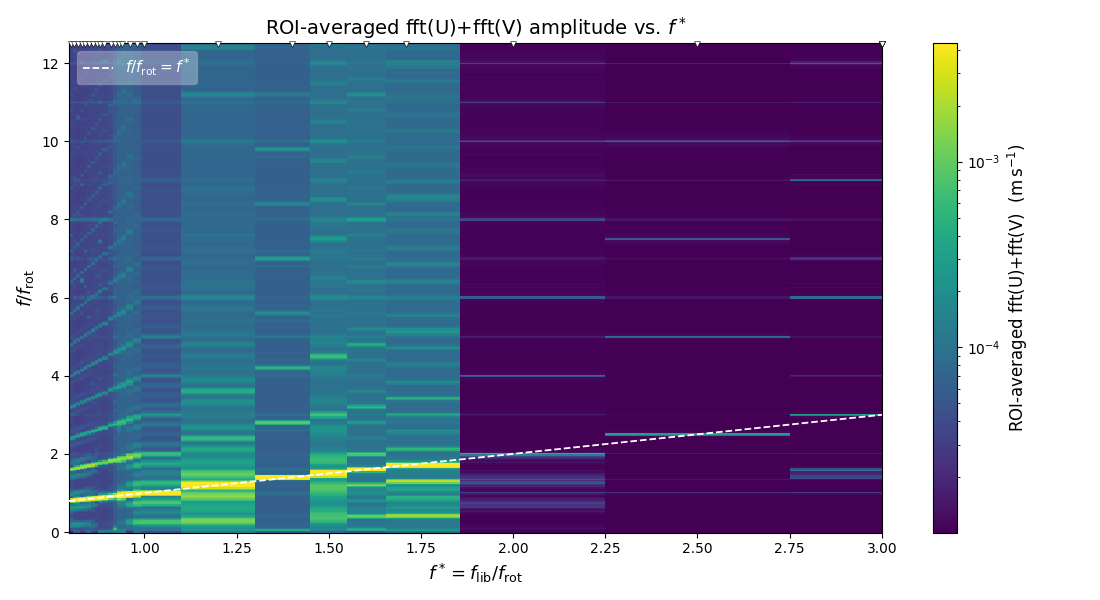

In [100]:
df = run_batch(reprocess_all=REPROCESS_ALL)
df.head(40)


## Colormap vs. $\delta\phi$ at a fixed $f_{\mathrm{lib}}$

Uses `VelocityFFT_summary.csv` (written by `run_batch`) to list the available
libration frequencies, then plots amplitude with **x = $\delta\phi$**,
**y = $f/f_{\mathrm{rot}}$** at the single $f_{\mathrm{lib}}$ set by
`PLOT_FIX_FLIB` (leave it `None` to take the first available and see the list).
The component follows `PLOT_COMPONENT`.

Available f_lib (Hz): ['0.4', '0.405', '0.41', '0.415', '0.42', '0.425', '0.43', '0.435', '0.44', '0.445', '0.455', '0.46', '0.465', '0.47', '0.48', '0.49', '0.5', '0.6', '0.7', '0.75', '0.8', '0.855', '1', '1.25', '1.5']
Colormap written to:
  /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/k6_TopBottom/VelocityFFT_colormap_dphi_flib1.5Hz_total.png


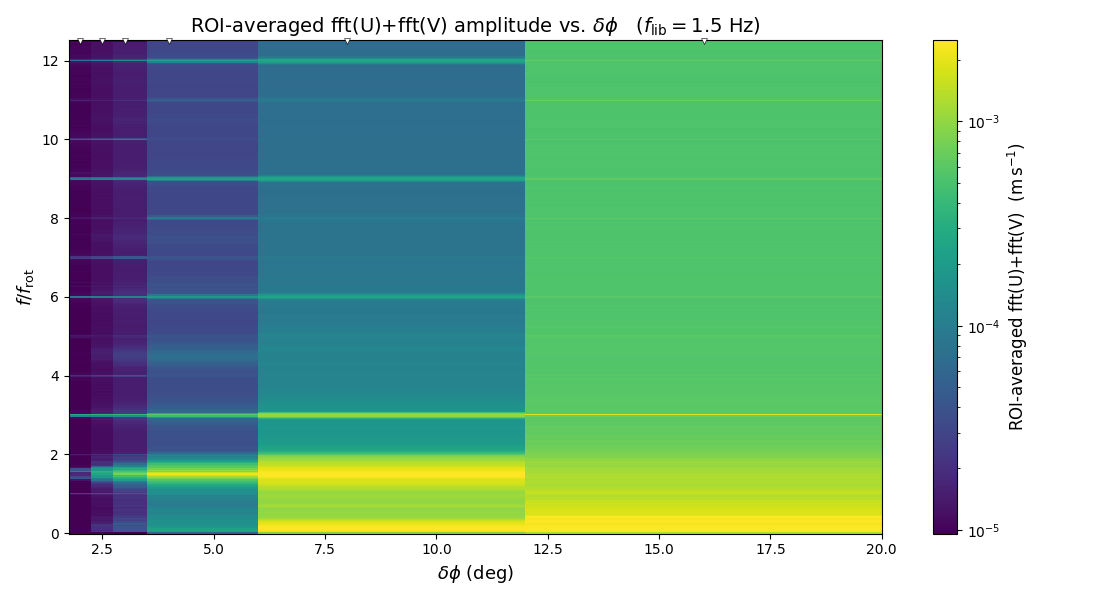

In [101]:
_ = plot_colormap_dphi(BASE_DIR, flib_hz=PLOT_FIX_FLIB)

## Colormap vs. $f_{\mathrm{lib}}$ at a fixed $\delta\phi$

Mirror of the previous plot with the axes' roles swapped: **x = $f_{\mathrm{lib}}$**,
**y = $f/f_{\mathrm{rot}}$**, at the single $\delta\phi$ set by `PLOT_FIX_DPHI`
(leave it `None` to take the first available and print the list). Component
follows `PLOT_COMPONENT`.

Available dphi (deg): ['2', '2.5', '3', '4', '8', '16']
PLOT_FIX_DPHI is None -> using first available dphi = 2 deg
Colormap written to:
  /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/k6_TopBottom/VelocityFFT_colormap_flib_dphi2deg_total.png


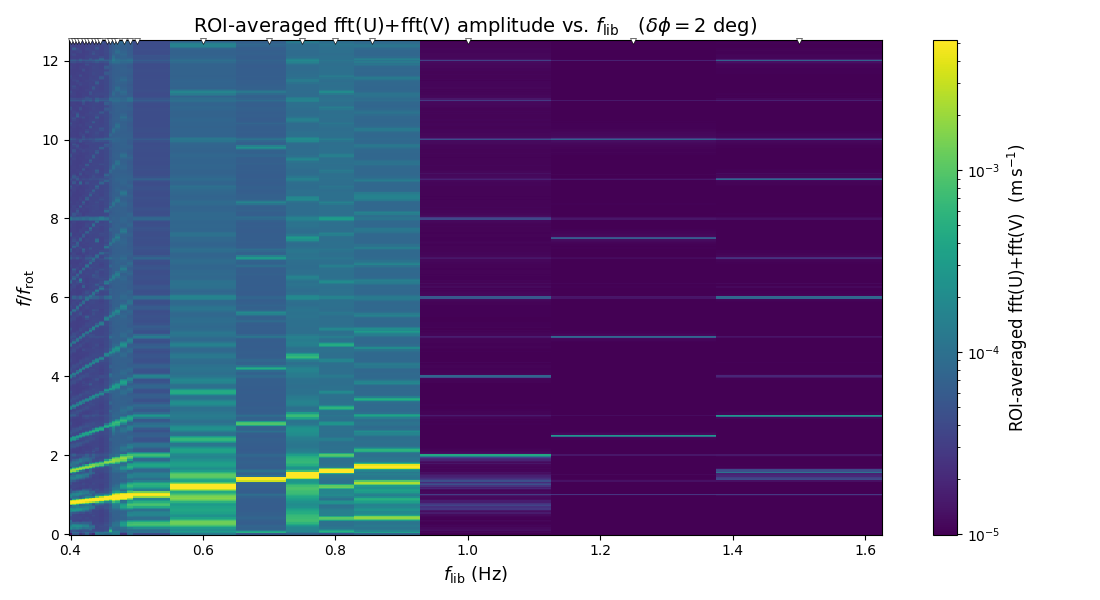

In [102]:
_ = plot_colormap_flib(BASE_DIR, dphi_deg=PLOT_FIX_DPHI)